# 02. Preprocessing — Split estratificado por raster

Este notebook implementa la partición **train / val / test** a nivel de raster (`tif_source`),
evitando fuga de datos espacial entre chips del mismo `.tif`.

Basado en las conclusiones del EDA (`01_eda_dataset`):
- 111 584 chips provenientes de **12 rasters** únicos.
- Alto solapamiento espacial entre chips vecinos.
- Split aleatorio por chip infla métricas; split por raster es la evaluación honesta.
- Con solo 12 rasters, el split debe ser **estratificado** por `% minería` para no desbalancear val/test.

## 1. Configuración

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ── Rutas ──────────────────────────────────────────────────────────────────
DATA_RAW = Path("../data/01_raw")
DATA_INTERMEDIATE = Path("../data/02_intermediate")
DATA_MODEL_INPUT = Path("../data/05_model_input")

MANIFEST_PATH = DATA_RAW / "manifesto_chips.csv"
CHIPS_DIR = DATA_RAW / "dataset_amazonia_garimpo_binario"

OUTPUT_MANIFEST = DATA_INTERMEDIATE / "manifest_with_split.csv"
OUTPUT_RASTER_MAP = DATA_INTERMEDIATE / "raster_split_map.csv"
OUTPUT_SUMMARY = DATA_INTERMEDIATE / "split_summary.csv"

# ── Hiperparámetros del split ───────────────────────────────────────────────
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
RANDOM_STATE = 42

# Bandas de % minería (mismas que en el EDA, sección 11.4)
MINING_BINS = [0, 1, 25, 50, 75, 100]
MINING_LABELS = ["0%", "1-25%", "25-50%", "50-75%", "75-100%"]

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-9, "Las proporciones deben sumar 1.0"

## 2. Carga del manifesto

In [2]:
df = pd.read_csv(MANIFEST_PATH)
df["full_path"] = df["png_path"].apply(lambda x: CHIPS_DIR / x)

print(f"Chips totales : {len(df):,}")
print(f"Rasters únicos: {df['tif_source'].nunique()}")
print(f"Balance global:\n{df['label_str'].value_counts(normalize=True).mul(100).round(2)}")

Chips totales : 111,584
Rasters únicos: 12
Balance global:
label_str
sem_garimpo    50.22
com_garimpo    49.78
Name: proportion, dtype: float64


## 3. Resumen por raster

Agregamos estadísticas a nivel de `tif_source` para estratificar el split.

In [3]:
def build_raster_summary(chips: pd.DataFrame) -> pd.DataFrame:
    """Construye tabla de resumen por raster con conteos y % de minería."""
    summary = (
        chips.groupby(["tif_source", "label_str"])
        .size()
        .unstack(fill_value=0)
        .rename(columns={"com_garimpo": "com_garimpo", "sem_garimpo": "sem_garimpo"})
    )

    for col in ["com_garimpo", "sem_garimpo"]:
        if col not in summary.columns:
            summary[col] = 0

    summary = summary[["com_garimpo", "sem_garimpo"]]
    summary["total_chips"] = summary["com_garimpo"] + summary["sem_garimpo"]
    summary["mining_ratio"] = (
        summary["com_garimpo"] / summary["total_chips"] * 100
    ).round(2)
    summary["mining_band"] = pd.cut(
        summary["mining_ratio"],
        bins=MINING_BINS,
        labels=MINING_LABELS,
        include_lowest=True,
        right=True,
    )
    return summary.sort_values("total_chips", ascending=False)


raster_summary = build_raster_summary(df)
print(raster_summary[["com_garimpo", "sem_garimpo", "total_chips", "mining_ratio", "mining_band"]])
print("\nRasters por banda de minería:")
print(raster_summary["mining_band"].value_counts().sort_index())

label_str                                           com_garimpo  sem_garimpo  \
tif_source                                                                     
v3_new_ret_s2_median_2024_dry-0000000000-000000...         5229         6007   
v3_new_ret_s2_median_2024_dry-0000000000-000001...         6705         4531   
v3_new_ret_s2_median_2024_dry-0000013568-000000...         6493         4743   
v3_new_ret_s2_median_2024_dry-0000013568-000001...        10025         1211   
v3_new_ret_s2_median_2024_dry-0000027136-000001...         6371         4865   
v3_new_ret_s2_median_2024_dry-0000027136-000000...          673        10563   
v3_new_ret_s2_median_2024_dry-0000000000-000002...         2618         8512   
v3_new_ret_s2_median_2024_dry-0000013568-000002...         6117         5013   
v3_new_ret_s2_median_2024_dry-0000027136-000002...         9132         1998   
v3_new_ret_s2_median_2024_dry-0000040704-000000...           18         3586   
v3_new_ret_s2_median_2024_dry-0000040704

## 4. Split estratificado por raster

Asignación **greedy por banda de minería**: dentro de cada banda, los rasters se reparten
entre train/val/test priorizando el split que aún está más lejos de su cuota objetivo.
Así cada partición recibe una mezcla de rasters con distinto `% com_garimpo`.

In [4]:
def _split_targets(
    n_rasters: int,
    train_ratio: float,
    val_ratio: float,
    test_ratio: float,
) -> dict[str, int]:
    """Calcula cuántos rasters van a cada split (mínimo 1 en val y test si n >= 3)."""
    n_test = max(1, round(n_rasters * test_ratio))
    n_val = max(1, round(n_rasters * val_ratio))
    n_train = n_rasters - n_val - n_test

    if n_train < 1:
        raise ValueError(
            f"Con {n_rasters} rasters no caben las proporciones "
            f"{train_ratio:.0%}/{val_ratio:.0%}/{test_ratio:.0%}. "
            "Reduce val/test o usa GroupKFold."
        )

    return {"train": n_train, "val": n_val, "test": n_test}


def stratified_raster_split(
    raster_stats: pd.DataFrame,
    train_ratio: float = 0.70,
    val_ratio: float = 0.15,
    test_ratio: float = 0.15,
    random_state: int = 42,
) -> pd.Series:
    """
    Asigna cada tif_source a train/val/test estratificando por mining_band.

    Returns
    -------
    pd.Series
        Índice = tif_source, valores = 'train' | 'val' | 'test'
    """
    rng = np.random.default_rng(random_state)
    n_rasters = len(raster_stats)
    targets = _split_targets(n_rasters, train_ratio, val_ratio, test_ratio)

    assigned: dict[str, list[str]] = {split: [] for split in targets}

    for band in MINING_LABELS:
        band_rasters = raster_stats.index[
            raster_stats["mining_band"] == band
        ].tolist()
        rng.shuffle(band_rasters)

        for raster_id in band_rasters:
            # Elegir el split más "atrasado" respecto a su cuota objetivo
            split_name = min(
                targets.keys(),
                key=lambda s: len(assigned[s]) / targets[s],
            )
            assigned[split_name].append(raster_id)

    mapping = {
        raster_id: split_name
        for split_name, raster_ids in assigned.items()
        for raster_id in raster_ids
    }
    return pd.Series(mapping, name="split")


def naive_raster_split(
    raster_stats: pd.DataFrame,
    train_ratio: float = 0.70,
    val_ratio: float = 0.15,
    test_ratio: float = 0.15,
    random_state: int = 42,
) -> pd.Series:
    """Split aleatorio por raster (referencia del EDA — puede desbalancear val)."""
    rng = np.random.default_rng(random_state)
    n_rasters = len(raster_stats)
    targets = _split_targets(n_rasters, train_ratio, val_ratio, test_ratio)

    shuffled = raster_stats.sample(frac=1, random_state=random_state).index.tolist()
    train_ids = shuffled[: targets["train"]]
    val_ids = shuffled[targets["train"] : targets["train"] + targets["val"]]
    test_ids = shuffled[targets["train"] + targets["val"] :]

    mapping = {r: "train" for r in train_ids}
    mapping.update({r: "val" for r in val_ids})
    mapping.update({r: "test" for r in test_ids})
    return pd.Series(mapping, name="split_naive")


# ── Aplicar split estratificado (el que usaremos en entrenamiento) ───────────
raster_split = stratified_raster_split(
    raster_summary,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
    random_state=RANDOM_STATE,
)

raster_summary = raster_summary.join(raster_split)
df["split"] = df["tif_source"].map(raster_split)

# Referencia: split naive del EDA para comparar
raster_summary["split_naive"] = naive_raster_split(
    raster_summary,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
    random_state=RANDOM_STATE,
)

print("Asignación estratificada por raster:")
print(raster_summary[["mining_ratio", "mining_band", "split", "split_naive"]])

Asignación estratificada por raster:
                                                    mining_ratio mining_band  \
tif_source                                                                     
v3_new_ret_s2_median_2024_dry-0000000000-000000...         46.54      25-50%   
v3_new_ret_s2_median_2024_dry-0000000000-000001...         59.67      50-75%   
v3_new_ret_s2_median_2024_dry-0000013568-000000...         57.79      50-75%   
v3_new_ret_s2_median_2024_dry-0000013568-000001...         89.22     75-100%   
v3_new_ret_s2_median_2024_dry-0000027136-000001...         56.70      50-75%   
v3_new_ret_s2_median_2024_dry-0000027136-000000...          5.99       1-25%   
v3_new_ret_s2_median_2024_dry-0000000000-000002...         23.52       1-25%   
v3_new_ret_s2_median_2024_dry-0000013568-000002...         54.96      50-75%   
v3_new_ret_s2_median_2024_dry-0000027136-000002...         82.05     75-100%   
v3_new_ret_s2_median_2024_dry-0000040704-000000...          0.50          0%   
v3_

## 5. Resumen del split

Comparamos el split **estratificado** vs el **naive** (aleatorio) a nivel de chips.

In [5]:
def split_report(chips: pd.DataFrame, split_col: str = "split") -> pd.DataFrame:
    """Tabla resumen: chips, rasters y % com_garimpo por partición."""
    rows = []
    for partition in ["train", "val", "test"]:
        sub = chips[chips[split_col] == partition]
        class_pct = sub["label_str"].value_counts(normalize=True).mul(100).round(1)
        rows.append(
            {
                "split": partition,
                "n_chips": len(sub),
                "n_rasters": sub["tif_source"].nunique(),
                "com_garimpo_%": class_pct.get("com_garimpo", 0.0),
                "sem_garimpo_%": class_pct.get("sem_garimpo", 0.0),
            }
        )
    return pd.DataFrame(rows)


df["split_naive"] = df["tif_source"].map(raster_summary["split_naive"])

report_stratified = split_report(df, "split")
report_naive = split_report(df, "split_naive")

print("═══ Split ESTRATIFICADO por raster ═══")
print(report_stratified.to_string(index=False))

print("\n═══ Split NAIVE por raster (referencia EDA) ═══")
print(report_naive.to_string(index=False))

print("\nRasters por split (estratificado):")
for partition in ["train", "val", "test"]:
    rasters = raster_summary[raster_summary["split"] == partition]
    print(f"\n  [{partition.upper()}] — {len(rasters)} raster(s)")
    print(rasters[["total_chips", "mining_ratio", "mining_band"]].to_string())

═══ Split ESTRATIFICADO por raster ═══
split  n_chips  n_rasters  com_garimpo_%  sem_garimpo_%
train    81938          8           56.1           43.9
  val    14840          2           45.3           54.7
 test    14806          2           19.1           80.9

═══ Split NAIVE por raster (referencia EDA) ═══
split  n_chips  n_rasters  com_garimpo_%  sem_garimpo_%
train    66852          8           45.5           54.5
  val    22366          2           55.8           44.2
 test    22366          2           56.5           43.5

Rasters por split (estratificado):

  [TRAIN] — 8 raster(s)
                                                         total_chips  mining_ratio mining_band
tif_source                                                                                    
v3_new_ret_s2_median_2024_dry-0000000000-0000000000.tif        11236         46.54      25-50%
v3_new_ret_s2_median_2024_dry-0000013568-0000000000.tif        11236         57.79      50-75%
v3_new_ret_s2_median_20

## 6. Validaciones de integridad

In [6]:
def validate_split(chips: pd.DataFrame, raster_map: pd.Series) -> None:
    """Comprueba que no haya fuga espacial ni chips sin asignar."""
    assert chips["split"].notna().all(), "Hay chips sin split asignado."
    assert set(chips["split"]) <= {"train", "val", "test"}, "Split inválido."

    # Ningún raster en más de un split
    raster_to_splits = chips.groupby("tif_source")["split"].nunique()
    leaked = raster_to_splits[raster_to_splits > 1]
    assert leaked.empty, f"Rasters en múltiples splits: {leaked.index.tolist()}"

    # Todos los rasters del mapa están en el dataframe
    assert set(raster_map.index) == set(chips["tif_source"].unique())

    print("Validación OK:")
    print(f"  - {chips['tif_source'].nunique()} rasters, cada uno en un único split")
    print(f"  - {len(chips):,} chips con split asignado")
    print(f"  - Sin solapamiento de rasters entre train/val/test")


validate_split(df, raster_split)

Validación OK:
  - 12 rasters, cada uno en un único split
  - 111,584 chips con split asignado
  - Sin solapamiento de rasters entre train/val/test


## 7. Guardar artefactos

Los archivos generados alimentan el pipeline de entrenamiento (`05_model_input`).

In [7]:
DATA_INTERMEDIATE.mkdir(parents=True, exist_ok=True)
DATA_MODEL_INPUT.mkdir(parents=True, exist_ok=True)

# Manifest completo con columna split
export_cols = [
    "png_path",
    "tif_source",
    "label_str",
    "label_int",
    "split",
    "tile_row",
    "tile_col",
    "centroid_lon",
    "centroid_lat",
]
df[export_cols].to_csv(OUTPUT_MANIFEST, index=False)

# Mapa raster → split (referencia rápida)
raster_summary[[
    "com_garimpo",
    "sem_garimpo",
    "total_chips",
    "mining_ratio",
    "mining_band",
    "split",
]].reset_index().rename(columns={"index": "tif_source"}).to_csv(
    OUTPUT_RASTER_MAP, index=False
)

# Resumen numérico del split
report_stratified.to_csv(OUTPUT_SUMMARY, index=False)

# Manifests por partición (copia en 05_model_input)
for partition in ["train", "val", "test"]:
    part_path = DATA_MODEL_INPUT / f"manifest_{partition}.csv"
    df.loc[df["split"] == partition, export_cols].to_csv(part_path, index=False)

print("Archivos guardados:")
print(f"  {OUTPUT_MANIFEST}")
print(f"  {OUTPUT_RASTER_MAP}")
print(f"  {OUTPUT_SUMMARY}")
print(f"  {DATA_MODEL_INPUT}/manifest_train.csv")
print(f"  {DATA_MODEL_INPUT}/manifest_val.csv")
print(f"  {DATA_MODEL_INPUT}/manifest_test.csv")

Archivos guardados:
  ..\data\02_intermediate\manifest_with_split.csv
  ..\data\02_intermediate\raster_split_map.csv
  ..\data\02_intermediate\split_summary.csv
  ..\data\05_model_input/manifest_train.csv
  ..\data\05_model_input/manifest_val.csv
  ..\data\05_model_input/manifest_test.csv


## 8. Visualización

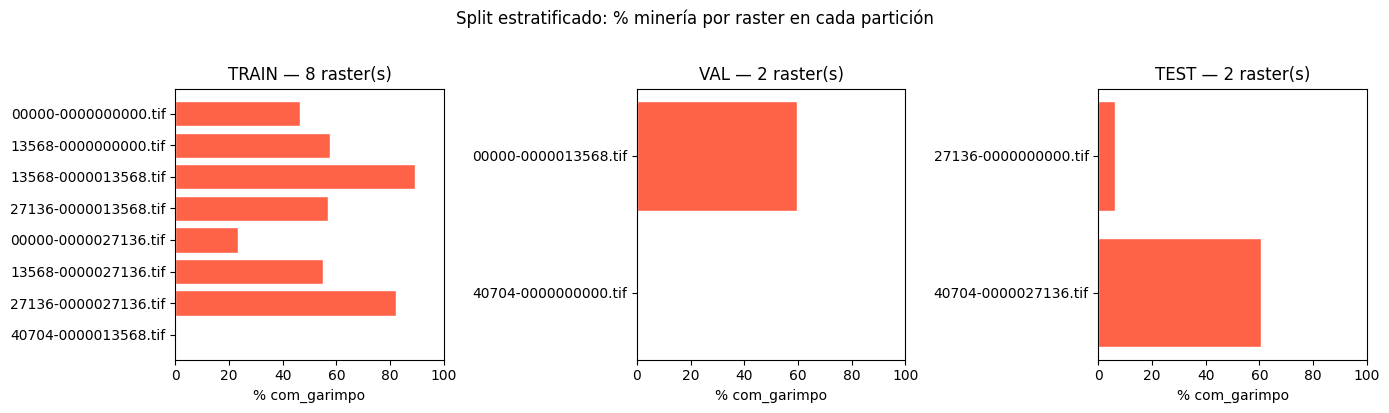

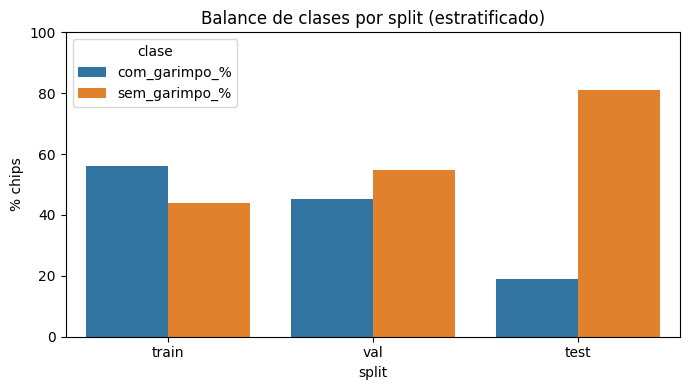

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, partition in zip(axes, ["train", "val", "test"]):
    sub = raster_summary[raster_summary["split"] == partition]
    ax.barh(sub.index.str[-20:], sub["mining_ratio"], color="tomato", edgecolor="white")
    ax.set_title(f"{partition.upper()} — {len(sub)} raster(s)")
    ax.set_xlabel("% com_garimpo")
    ax.set_xlim(0, 100)
    ax.invert_yaxis()

plt.suptitle("Split estratificado: % minería por raster en cada partición", y=1.02)
plt.tight_layout()
plt.show()

# Balance de clases por split
fig, ax = plt.subplots(figsize=(7, 4))
plot_df = report_stratified.melt(
    id_vars="split",
    value_vars=["com_garimpo_%", "sem_garimpo_%"],
    var_name="clase",
    value_name="porcentaje",
)
sns.barplot(data=plot_df, x="split", y="porcentaje", hue="clase", ax=ax)
ax.set_title("Balance de clases por split (estratificado)")
ax.set_ylabel("% chips")
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

## 9. (Opcional) GroupKFold para validación cruzada

Con solo 12 rasters, también puedes usar **Leave-One-Raster-Out** o GroupKFold
donde cada fold de validación contiene rasters completos (sin fuga espacial).

In [9]:
from sklearn.model_selection import GroupKFold

N_FOLDS = min(5, df["tif_source"].nunique())  # máx. 5 folds con 12 grupos

gkf = GroupKFold(n_splits=N_FOLDS)
groups = df["tif_source"]

print(f"GroupKFold con {N_FOLDS} folds (grupo = tif_source):\n")
for fold, (train_idx, val_idx) in enumerate(gkf.split(df, groups=groups), start=1):
    train_r = groups.iloc[train_idx].nunique()
    val_r = groups.iloc[val_idx].nunique()
    val_chips = df.iloc[val_idx]
    val_pct = val_chips["label_str"].value_counts(normalize=True).mul(100).round(1)
    com = val_pct.get("com_garimpo", 0)
    sem = val_pct.get("sem_garimpo", 0)
    print(
        f"  Fold {fold}: train={len(train_idx):>6,} chips ({train_r} rasters) | "
        f"val={len(val_idx):>6,} chips ({val_r} rasters) | "
        f"val balance: com={com}% sem={sem}%"
    )

GroupKFold con 5 folds (grupo = tif_source):

  Fold 1: train=89,112 chips (10 rasters) | val=22,472 chips (2 rasters) | val balance: com=58.7% sem=41.3%
  Fold 2: train=89,218 chips (10 rasters) | val=22,366 chips (2 rasters) | val balance: com=72.2% sem=27.8%
  Fold 3: train=89,218 chips (10 rasters) | val=22,366 chips (2 rasters) | val balance: com=43.8% sem=56.2%
  Fold 4: train=89,218 chips (10 rasters) | val=22,366 chips (2 rasters) | val balance: com=40.2% sem=59.8%
  Fold 5: train=89,570 chips (8 rasters) | val=22,014 chips (4 rasters) | val balance: com=33.6% sem=66.4%
